In [12]:
import sqlite3
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
from babel.dates import format_datetime
import contextily as ctx
import seaborn as sns


from meteostat import Point, Hourly
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score, mean_squared_error
import xgboost as xgb
import optuna

In [2]:
conn = sqlite3.connect("my_data.db")

# Load the merged data
data_stations = pd.read_sql("SELECT * FROM stations", conn)
data_localisation = pd.read_sql("SELECT * FROM localisation", conn)

conn.close()

In [3]:
plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.facecolor"] = 'w'

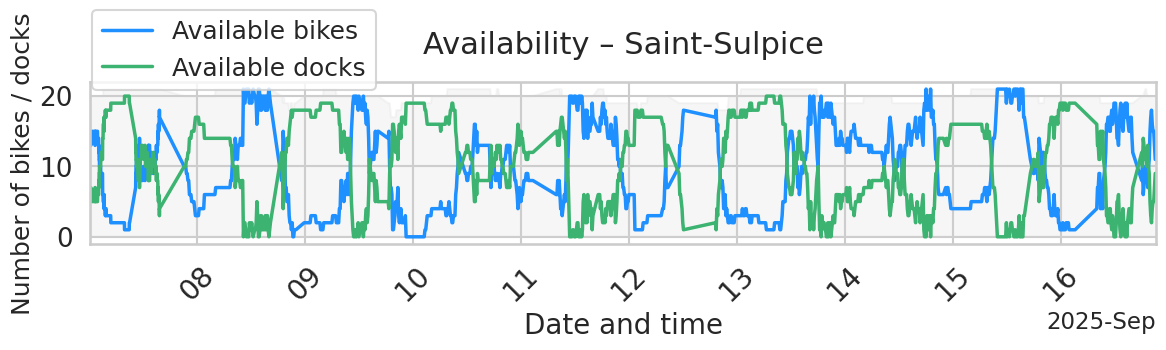

In [4]:
# --- Selecting a specific station ---
station_id = 37874517  # 👉 Change the ID to the station you want
station_data = data_stations[data_stations["station_id"] == station_id].copy()
station_info = data_localisation[data_localisation["station_id"] == station_id]

# Convert to datetime and sort
station_data["time_stamp"] = pd.to_datetime(station_data["time_stamp"], errors="coerce")
station_data = station_data.sort_values("time_stamp")

sns.set_style("whitegrid")
sns.set_context("talk")

fig, ax = plt.subplots(figsize=(12, 5))  # Slightly taller figure

ax.plot(station_data["time_stamp"], station_data["num_bikes_available"],
        linestyle='-', linewidth=2.5, color='dodgerblue', label='Available bikes')  # Thicker line
ax.plot(station_data["time_stamp"], station_data["num_docks_available"],
        linestyle='-', linewidth=2.5, color='mediumseagreen', label='Available docks')  # Thicker line

# Fill between for overall capacity
ax.fill_between(station_data["time_stamp"], 0,
                station_data["num_bikes_available"] + station_data["num_docks_available"],
                color='lightgray', alpha=0.2)

# X-axis formatting
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.tick_params(axis='x', rotation=45, labelsize=20)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.tick_params(axis='x', rotation=45, labelsize=20)  # Larger tick labels
ax.tick_params(axis='y', labelsize=19)  # Larger tick labels

# Titles and labels with larger font sizes
station_name = station_info['name'].values[0] if not station_info.empty else f"Station {station_id}"
ax.set_title(f"Availability – {station_name}", fontsize=22, pad=20)  # Larger title
ax.set_ylabel("Number of bikes / docks", fontsize=18)  # Larger y-label
ax.set_xlabel("Date and time", fontsize=20)  # Larger x-label

#filter to avoid clutter
start_date = pd.to_datetime("2025-09-07 00:15:00")
end_date = pd.to_datetime("2025-09-16 21:06:59")
ax.set_xlim(start_date, end_date)

# Legend with larger text
ax.legend(loc='upper left', bbox_to_anchor=(-0.01, 1.52), fontsize=18)

plt.tight_layout()
#plt.savefig("station_availability.png", dpi=150, bbox_inches='tight')
plt.show()

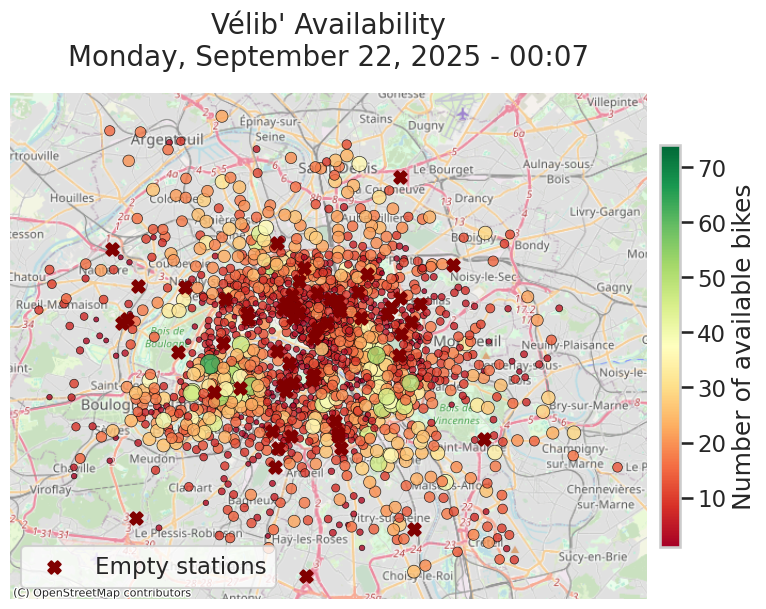

In [5]:
data_stations = data_stations.merge(data_localisation, on="station_id")

# Conversion to GeoDataFrame
geometry = gpd.points_from_xy(data_stations["lon"], data_stations["lat"])
geo_stations = gpd.GeoDataFrame(data_stations, crs="EPSG:4326", geometry=geometry)

# Convert timestamp to datetime
geo_stations["time_stamp"] = pd.to_datetime(geo_stations["time_stamp"])

# Select the latest timestamp
some_time = geo_stations["time_stamp"].max()
some_data = geo_stations[geo_stations["time_stamp"] == some_time].copy()
some_data = some_data.to_crs(epsg=3857)

# --- Create the map ---
fig, ax = plt.subplots(figsize=(8, 8))

# Separate empty and non-empty stations
empty_stations = some_data[some_data["num_bikes_available"] == 0]
non_empty_stations = some_data[some_data["num_bikes_available"] > 0]

# Plot non-empty stations (color gradient)
non_empty_stations.plot(
    column="num_bikes_available", 
    markersize=non_empty_stations["num_bikes_available"] * 3 + 10,
    cmap="RdYlGn", 
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    legend=False,
    ax=ax
)

# Plot empty stations (dark red crosses)
empty_stations.plot(
    ax=ax,
    markersize=80,
    marker="X",
    color="#800000",
    label="Empty stations"
)

# Add a compact colorbar
if not non_empty_stations.empty:
    sm = plt.cm.ScalarMappable(
        cmap="RdYlGn",
        norm=plt.Normalize(
            vmin=non_empty_stations["num_bikes_available"].min(),
            vmax=non_empty_stations["num_bikes_available"].max()
        )
    )
    sm._A = []  # Matplotlib hack
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Number of available bikes")

# Format date in English
date_str = format_datetime(some_time, "EEEE, MMMM d, y - HH:mm", locale="en_US")

# Title
ax.set_title(
    f"Vélib' Availability\n{date_str}",
    fontsize=20, pad=20
)

# Background map
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.8)

# Remove axes
ax.set_axis_off()

# Manual legend for the crosses
ax.legend(loc="lower left")

plt.tight_layout()
#plt.savefig("Velib_availability.png", dpi=150, bbox_inches='tight')
plt.show()

Districts found: ['Arts-et-Métiers', 'Belleville', 'Bercy', 'Champs-Elysées', 'Père-Lachaise']


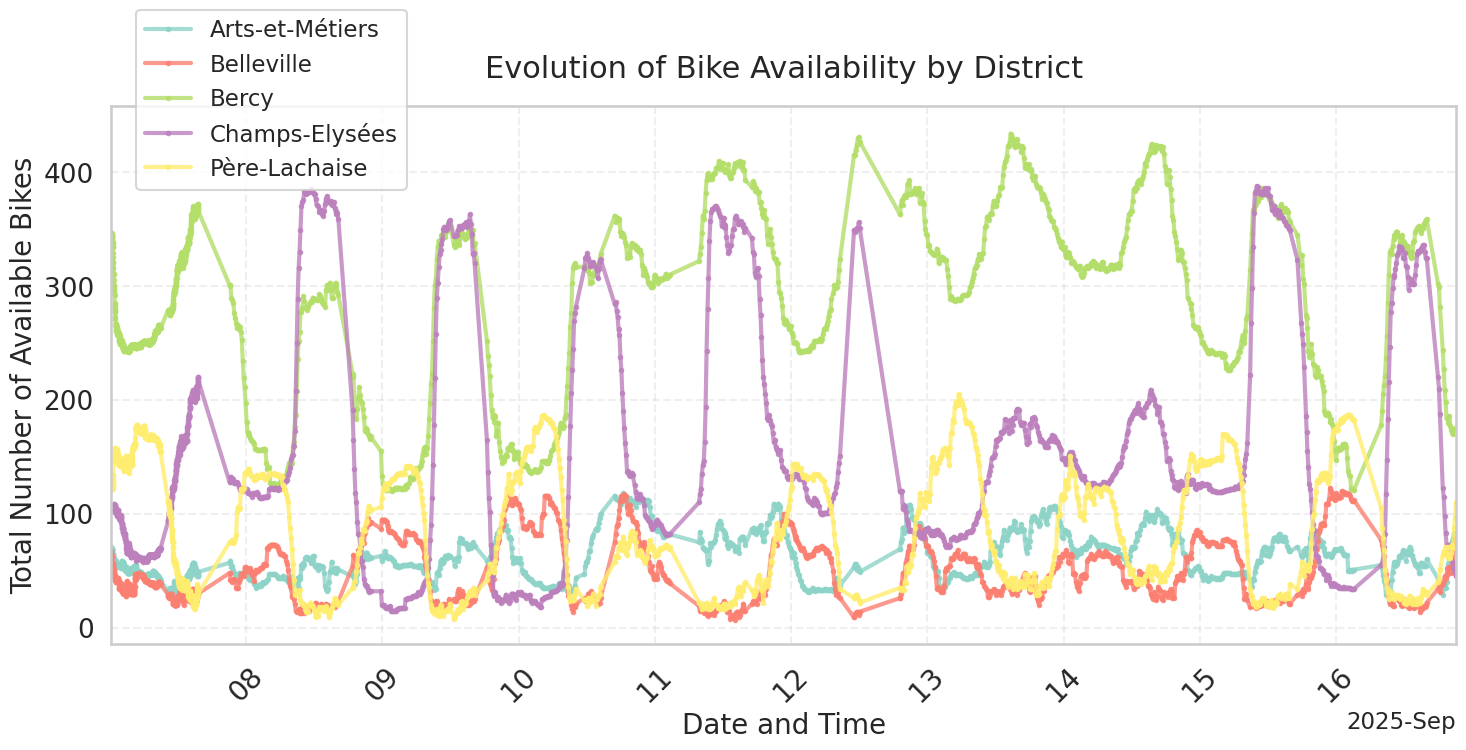

📊 Statistics by district:


,Mean,Max,Min,Std Dev
District,,,,
Arts-et-Métiers,54.1,118,10,19.9
Belleville,49.4,189,7,29.3
Bercy,282.8,437,120,74.8
Champs-Elysées,132.4,388,15,96.7
Père-Lachaise,94.0,205,8,53.4


In [6]:
# --- Load districts ---
districts = gpd.read_file("quartier_paris.geojson")

# --- Merge stations + location tables ---
data_merged = data_stations

# Convert to GeoDataFrame
geo_stations = gpd.GeoDataFrame(
    data_merged,
    crs="EPSG:4326",
    geometry=gpd.points_from_xy(data_merged["lon"], data_merged["lat"])
)

# Clean unnecessary columns
cols_to_drop_stations = ["stationCode", "name", "lon", "lat"] + [col for col in geo_stations.columns if 'index' in col]
geo_stations.drop(columns=cols_to_drop_stations, errors='ignore', inplace=True)
cols_to_drop_districts = ["n_sq_qu", "n_sq_ar", "c_qu", "surface", "perimetre", "c_quinsee", "c_ar"]
districts.drop(columns=cols_to_drop_districts, errors='ignore', inplace=True)

# Spatial join
geo_districts = gpd.sjoin(districts, geo_stations, how="left", predicate="contains")

# Aggregation by district and time
occupation_data = geo_districts.groupby(["l_qu", "time_stamp"], as_index=False).agg({
    "num_bikes_available": "sum",
    "geometry": "first"
})

# Convert timestamp
occupation_data["time_stamp"] = pd.to_datetime(occupation_data["time_stamp"])

# --- FILTER: Specific districts ---
selected_districts = [
    "Arts-et-Métiers", 
    "Bercy", 
    "Champs-Elysées",  
    "Belleville",
    "Père-Lachaise"
]
occupation_data_filtered = occupation_data[occupation_data["l_qu"].isin(selected_districts)]
found_districts = occupation_data_filtered["l_qu"].unique()
print(f"Districts found: {list(found_districts)}")

# --- Create the plot ---
fig, ax = plt.subplots(figsize=(15, 8))

# Colors for districts
colors = plt.cm.Set3(np.linspace(0, 1, len(found_districts)))

# Plot districts
for i, district in enumerate(found_districts):
    district_data = occupation_data_filtered[occupation_data_filtered["l_qu"] == district].sort_values("time_stamp")
    ax.plot(district_data["time_stamp"], district_data["num_bikes_available"],
            label=district, linewidth=3, alpha=0.8, color=colors[i],marker='o', markersize=3)

# Format X-axis with AutoDateLocator + ConciseDateFormatter
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.tick_params(axis='x', rotation=45, labelsize=20)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.tick_params(axis='y', labelsize=19)  # Larger tick labels




# Title and labels
ax.set_title("Evolution of Bike Availability by District",
             fontsize=22, pad=20)
ax.set_ylabel("Total Number of Available Bikes", fontsize=20)
ax.set_xlabel("Date and Time", fontsize=20)

# Grid + legend
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(bbox_to_anchor=(0.01, 1.2), loc='upper left', frameon=True, fancybox=True)


#filter to avoid clutter
start_date = pd.to_datetime("2025-09-07 00:15:00")
end_date = pd.to_datetime("2025-09-16 21:06:59")
ax.set_xlim(start_date, end_date)

plt.tight_layout()
#plt.savefig("evoBYdistrict.png", dpi=150, bbox_inches='tight')
plt.show()

# --- District statistics ---
district_stats = occupation_data_filtered.groupby("l_qu")["num_bikes_available"].agg(['mean', 'max', 'min', 'std'])
district_stats = district_stats.rename(columns={
    'mean': 'Mean', 
    'max': 'Max', 
    'min': 'Min', 
    'std': 'Std Dev'
})
district_stats.index.name = "District"
print("📊 Statistics by district:")
display(district_stats.round(1))

🚴 1492 stations analyzed (after cleaning):
🔍 150 atypical stations detected


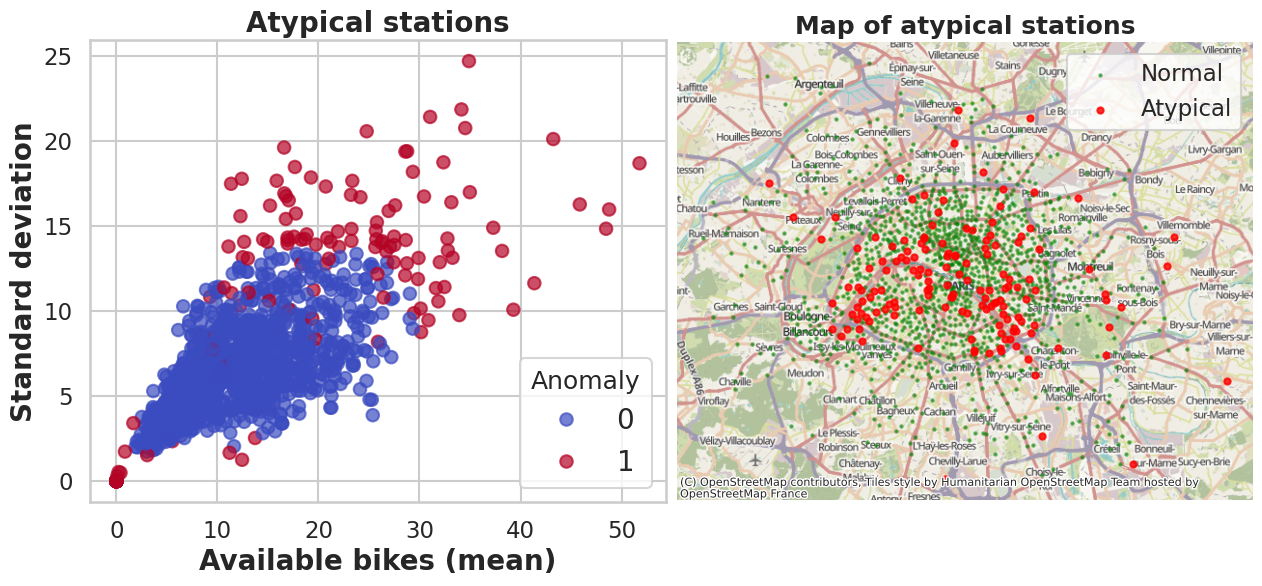


🚨 Always full stations (over-utilization): 32
🚨 Always empty stations (under-utilization): 22


In [7]:
# Station analysis with NaN handling
station_behavior = data_merged.groupby('station_id').agg({
    'num_bikes_available': ['mean', 'std', 'count'],
    'num_docks_available': ['mean', 'std'],
    'lat': 'first',
    'lon': 'first'
})

station_behavior.columns = ['_'.join(col).strip() for col in station_behavior.columns.values]

# Filter stations with enough data and no NaN values
station_behavior_clean = station_behavior[
    (station_behavior['num_bikes_available_count'] > 10) &
    (station_behavior['num_bikes_available_mean'].notna()) &
    (station_behavior['num_bikes_available_std'].notna())
].copy()

print(f"🚴 {len(station_behavior_clean)} stations analyzed (after cleaning):")

if len(station_behavior_clean) > 10:  # Minimum for analysis
    # Features for anomaly detection
    features = station_behavior_clean[['num_bikes_available_mean', 'num_bikes_available_std', 
                                    'num_docks_available_mean', 'num_docks_available_std']]
    
    # Anomaly detection with Isolation Forest
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    anomalies = iso_forest.fit_predict(features)
    
    station_behavior_clean['anomaly_score'] = iso_forest.decision_function(features)
    station_behavior_clean['is_anomaly'] = anomalies == -1
    
    print(f"🔍 {station_behavior_clean['is_anomaly'].sum()} atypical stations detected")
    
    # Anomaly visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'height_ratios': [1]})
    
    # --- Left panel: Scatter ---
    scatter = axes[0].scatter(
        station_behavior_clean['num_bikes_available_mean'], 
        station_behavior_clean['num_bikes_available_std'],
        c=station_behavior_clean['is_anomaly'], cmap='coolwarm', alpha=0.7
    )
    axes[0].set_xlabel('Available bikes (mean)', fontweight='bold', fontsize=20)
    axes[0].set_ylabel('Standard deviation', fontweight='bold', fontsize=20)
    axes[0].set_title('Atypical stations', fontweight='bold', fontsize=20)
    axes[0].legend(*scatter.legend_elements(), title="Anomaly", fontsize=20)

    # Anomaly map
    anomaly_stations = station_behavior_clean[station_behavior_clean['is_anomaly']].copy()
    normal_stations = station_behavior_clean[~station_behavior_clean['is_anomaly']].copy()
    
    # --- Right panel: Map ---
    if not anomaly_stations.empty:
        anomaly_gdf = gpd.GeoDataFrame(
            anomaly_stations,
            geometry=gpd.points_from_xy(anomaly_stations['lon_first'], anomaly_stations['lat_first']),
            crs='EPSG:4326'
        ).to_crs(epsg=3857)
        
        normal_gdf = gpd.GeoDataFrame(
            normal_stations,
            geometry=gpd.points_from_xy(normal_stations['lon_first'], normal_stations['lat_first']),
            crs='EPSG:4326'
        ).to_crs(epsg=3857)
        
        normal_gdf.plot(ax=axes[1], color='green', markersize=3, alpha=0.5, label='Normal')
        anomaly_gdf.plot(ax=axes[1], color='red', markersize=20, alpha=0.8, label='Atypical')
        ctx.add_basemap(axes[1])
        axes[1].set_axis_off()
        axes[1].set_title('Map of atypical stations', fontweight='bold')
        axes[1].legend()
    
    # Align panels nicely
    plt.subplots_adjust(wspace=0.02)
    plt.savefig("Anomaly.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # --- Definition of always full/empty stations ---
    always_full = station_behavior_clean[
        (station_behavior_clean['num_bikes_available_mean'] == 0) &
        (station_behavior_clean['num_bikes_available_std'] == 0)
    ]
    always_empty = station_behavior_clean[
        (station_behavior_clean['num_docks_available_mean'] == 0) &
        (station_behavior_clean['num_docks_available_std'] == 0)
    ]
    
    # Detailed analysis of atypical stations
    if not anomaly_stations.empty:
        if not always_full.empty:
            print(f"\n🚨 Always full stations (over-utilization): {len(always_full)}")
        if not always_empty.empty:
            print(f"🚨 Always empty stations (under-utilization): {len(always_empty)}")
    else:
        print("✅ No atypical stations detected")
else:
    print("❌ Not enough stations with complete data for analysis")

📊 Time series shape: (80, 2473, 1)
🏷️ Districts analyzed: 80


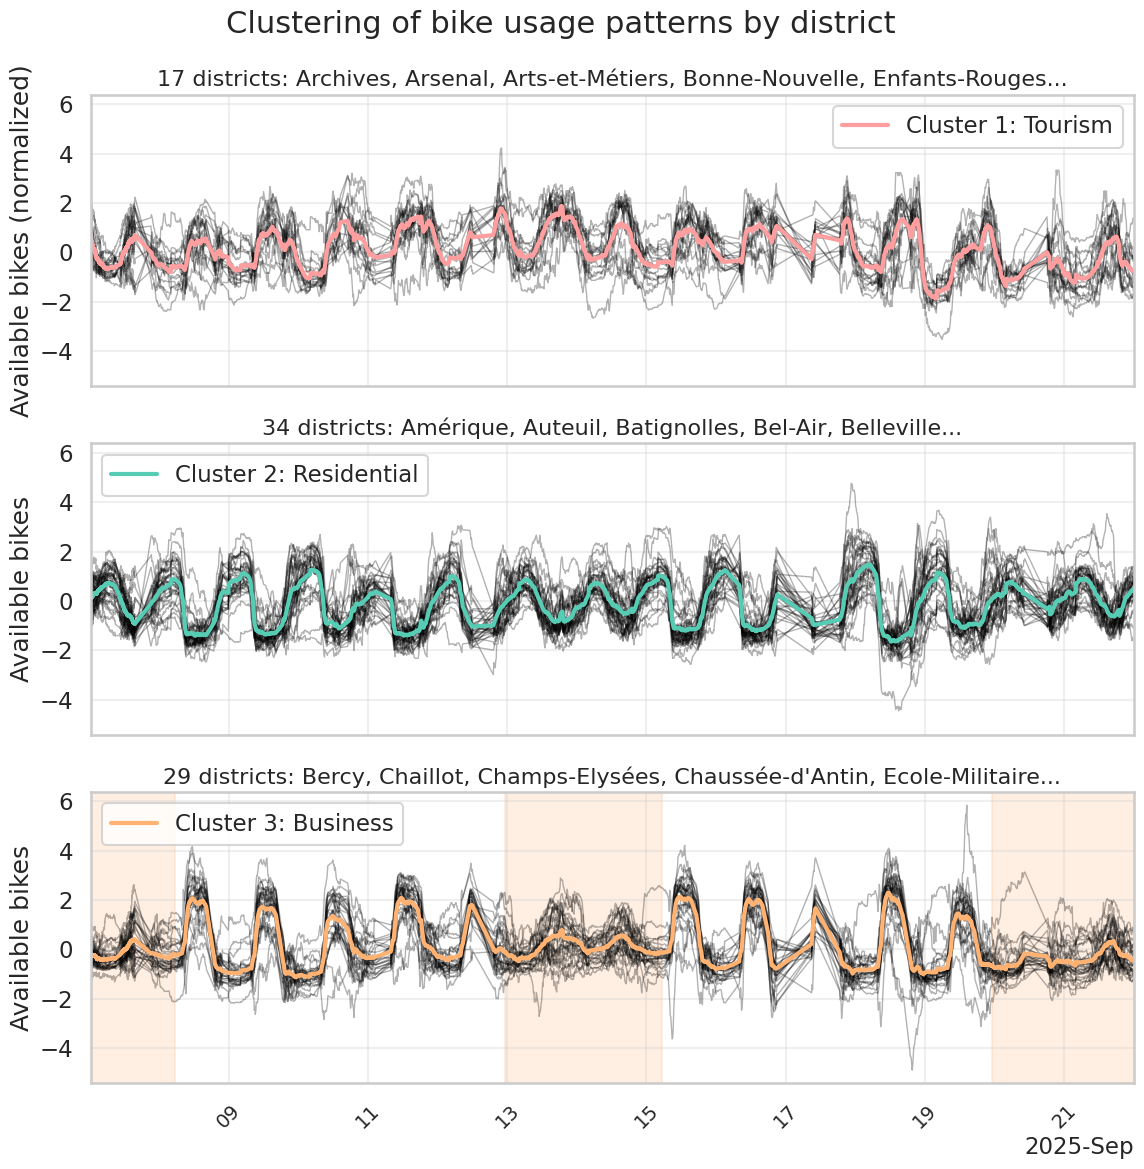


🎯 CLUSTER SUMMARY:
Cluster 1: 17 districts
   Districts: Archives, Arsenal, Arts-et-Métiers, Bonne-Nouvelle, Enfants-Rouges...
Cluster 2: 34 districts
   Districts: Amérique, Auteuil, Batignolles, Bel-Air, Belleville...
Cluster 3: 29 districts
   Districts: Bercy, Chaillot, Champs-Elysées, Chaussée-d'Antin, Ecole-Militaire...


In [8]:
# with 3 clusters
interpretation = ["Tourism","Residential","Business"]
colors = ["#FF9E9E","#56CCB5", "#FFB271"]

# --- Data preparation for clustering ---
labels, time_series_list = [], []
for l_qu, group in occupation_data.groupby("l_qu"):
    labels.append(l_qu)
    time_series_list.append(group["num_bikes_available"].values)

# Convert to time series format and normalize
time_series = to_time_series_dataset(time_series_list)
time_series = TimeSeriesScalerMeanVariance().fit_transform(time_series)

print(f"📊 Time series shape: {time_series.shape}")
print(f"🏷️ Districts analyzed: {len(labels)}")

# --- K-means clustering ---
n_classes = 3
model = TimeSeriesKMeans(n_clusters=n_classes, metric="euclidean", random_state=42)
model.fit(time_series)

# --- Cluster visualization ---
fig, axes = plt.subplots(n_classes, 1, figsize=(12, n_classes * 4), sharex=True, sharey=True)

time_labels = pd.to_datetime(occupation_data["time_stamp"].unique())
time_labels_sorted = sorted(time_labels)

# align X axis
x_min, x_max = min(time_labels_sorted), max(time_labels_sorted)

for yi, ax in enumerate(axes):
    # Series in this class
    for xx in time_series[model.labels_ == yi]:
        ax.plot(time_labels_sorted, xx.ravel(), "k-", alpha=.3, linewidth=1)
    
    # Class centroid with matching color
    ax.plot(time_labels_sorted, model.cluster_centers_[yi].ravel(), 
            color=colors[yi], linewidth=3, label=f'Cluster {yi+1}: {interpretation[yi]}')
    
    # X-axis formatting (partagé)
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', rotation=45, labelsize=14)

    # limits
    ax.set_xlim(x_min, x_max)

    # Y-axis
    ax.set_ylabel("Available bikes (normalized)" if yi == 0 else "Available bikes")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # District names in the cluster
    cluster_districts = [labels[i] for i in range(len(labels)) if model.labels_[i] == yi]
    districts_text = ", ".join(cluster_districts[:5]) + ("..." if len(cluster_districts) > 5 else "")
    ax.set_title(f"{len(cluster_districts)} districts: {districts_text}", fontsize=16)

    #shading
    if yi == 2:
        weekends = [
            ("2025-09-07 00:15:00", "2025-09-08 05:15:00"),
            ("2025-09-12 23:15:00", "2025-09-15 05:15:00"),
            ("2025-09-19 23:15:00", "2025-09-22 05:15:00"),
        ]
        for start, end in weekends:
            ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color=colors[yi], zorder=0)

# Title
plt.suptitle("Clustering of bike usage patterns by district", fontsize=22, y=0.98)
plt.tight_layout()
plt.savefig("TimeEVOcluster.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Cluster summary ---
print("\n🎯 CLUSTER SUMMARY:")
for yi in range(n_classes):
    cluster_indices = [i for i, label in enumerate(model.labels_) if label == yi]
    print(f"Cluster {yi+1}: {len(cluster_indices)} districts")
    print(f"   Districts: {', '.join([labels[i] for i in cluster_indices[:5]])}{'...' if len(cluster_indices) > 5 else ''}")


📋 District classification:


,l_qu,type
0,Monnaie,Tourism
1,Madeleine,Business
2,Sainte-Marguerite,Residential
3,Saint-Gervais,Tourism
4,Javel,Business


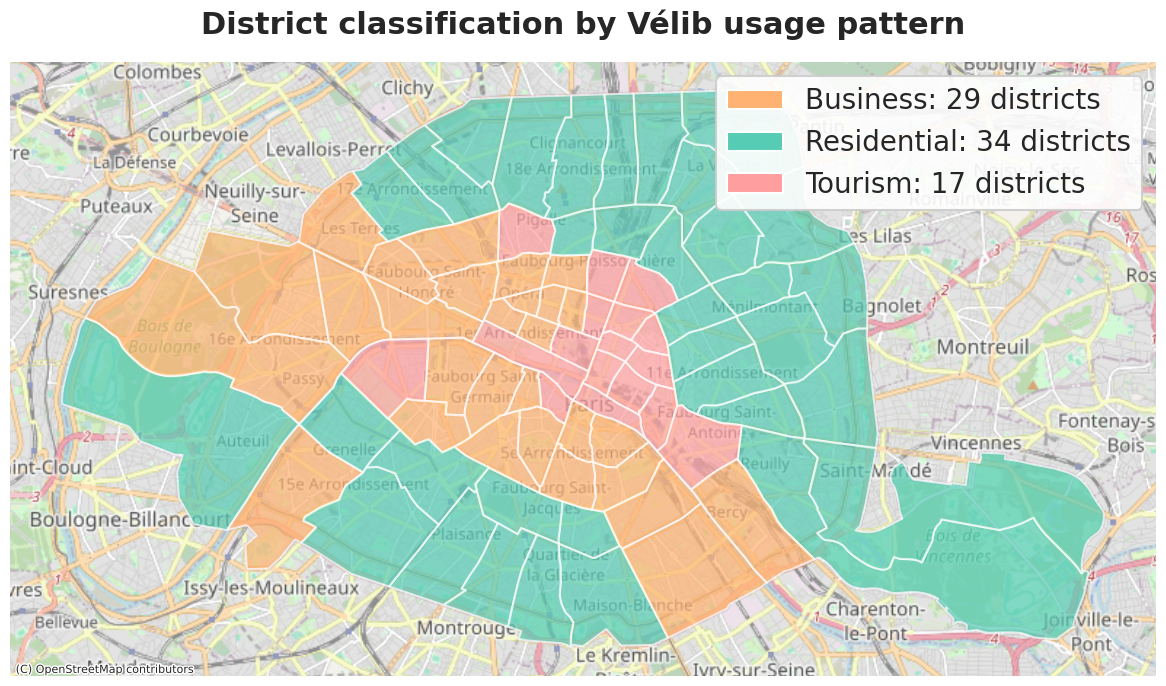


🎯 DISTRIBUTION BY TYPE:
type
Residential    34
Business       29
Tourism        17
Name: count, dtype: int64

📊 Total districts analyzed: 80


In [9]:
# --- Cluster interpretation and merge with districts ---

# Mapping cluster -> type
cluster_to_type = {
    2: "Business",
    1: "Residential",
    0: "Tourism"
}

type_to_color = {
    "Tourism": "#FF9E9E",
    "Residential": "#56CCB5",
    "Business": "#FFB271"
}

# Classification of districts
classification = pd.DataFrame({
    "l_qu": labels,
    "cluster": model.labels_,
})
classification["type"] = classification["cluster"].map(cluster_to_type)

districts_classified = districts.merge(classification, on="l_qu")

print("📋 District classification:")
display(districts_classified[["l_qu", "type"]].head())

# --- Mapping ---
fig, ax = plt.subplots(figsize=(12, 10))

# reprojection
districts_classified = districts_classified.to_crs(epsg=3857)

# Plot
districts_classified.plot(
    column="type",
    ax=ax,
    alpha=0.7,
    edgecolor="white",
    linewidth=1.5,
    categorical=True,
    cmap=ListedColormap([type_to_color[t] for t in cluster_to_type.values()]),
    legend=False
)

# map
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    alpha=0.8
)

# Customisation
ax.set_title(
    "District classification by Vélib usage pattern",
    fontsize=22,
    fontweight='bold',
    pad=20
)
ax.set_axis_off()

# Légend
stats = districts_classified["type"].value_counts()
legend_elements = [
    Patch(facecolor=type_to_color[t], edgecolor='white',
          label=f"{t}: {stats[t]} districts")
    for t in cluster_to_type.values()
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1, 1),
    frameon=True,
    fontsize=20,
    framealpha=0.9
)

plt.tight_layout()
plt.savefig("ALLcluster.png", dpi=150, bbox_inches='tight')
plt.show()


print("\n🎯 DISTRIBUTION BY TYPE:")
print(stats)
print(f"\n📊 Total districts analyzed: {len(districts_classified)}")


In [10]:
# -----------------------------
# 1️⃣ Choose execution mode
# -----------------------------
FAST_MODE = {
    "n_splits": 2,
    "n_estimators": 50,
    "max_depth": 3,
    "learning_rate": 0.1
}

PROD_MODE = {
    "n_splits": 5,
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05
}

MODE = PROD_MODE  # or FAST_MODE

# -----------------------------
# 2️⃣ Define models
# -----------------------------
model_configs = [
    {
        'name': 'Base Model',
        'features': ['l_qu_encoded', 'hour', 'dayofweek'],
        'weather_data': False,
        'district_type': False
    },
    {
        'name': 'Weather Model', 
        'features': ['l_qu_encoded', 'hour', 'dayofweek', 'temperature', 'precip', 'wind_speed'],
        'weather_data': True,
        'district_type': False
    },
    {
        'name': 'Full Model',
        'features': ['l_qu_encoded', 'type_encoded', 'hour', 'dayofweek', 'temperature', 'precip', 'wind_speed'],
        'weather_data': True,
        'district_type': True
    }
]

# -----------------------------
# 3️⃣ Prepare data
# -----------------------------
occupation_data['time_stamp'] = pd.to_datetime(occupation_data['time_stamp'], errors='coerce')
occupation_data = occupation_data.sort_values('time_stamp')

# Temporal features
occupation_data['hour'] = occupation_data['time_stamp'].dt.hour
occupation_data['dayofweek'] = occupation_data['time_stamp'].dt.dayofweek

# Encode station ID
le_qu = LabelEncoder()
occupation_data['l_qu_encoded'] = le_qu.fit_transform(occupation_data['l_qu'])

# -----------------------------
# 4️⃣ Merge district type
# -----------------------------
if 'type_qu' in occupation_data.columns:
    occupation_data = occupation_data.drop(columns=['type_qu'])

districts_type = districts_classified[['l_qu', 'type']].copy()
districts_type.rename(columns={'type': 'type_qu'}, inplace=True)
occupation_data = occupation_data.merge(districts_type, on='l_qu', how='left')

# Encode district type
le_type = LabelEncoder()
occupation_data['type_encoded'] = le_type.fit_transform(occupation_data['type_qu'])

# -----------------------------
# 5️⃣ Function to fetch weather
# -----------------------------
def fetch_weather(df):
    weather_cols = ['temperature','precip','wind_speed']
    if all(col in df.columns for col in weather_cols):
        return df  # Already present
    
    print("Fetching weather data...")
    df['hour_floor'] = df['time_stamp'].dt.floor('h')
    location = Point(48.8566, 2.3522)  # Paris Montsouris
    start = df['hour_floor'].min()
    end = df['hour_floor'].max()

    weather = Hourly(location, start, end).fetch()[['temp','prcp','wspd']]
    weather = weather.rename(columns={'temp':'temperature','prcp':'precip','wspd':'wind_speed'})
    weather.index = weather.index.floor('h')
    weather.reset_index(inplace=True)
    weather = weather.rename(columns={'time':'hour_weather'})

    df = df.merge(
        weather,
        left_on='hour_floor',
        right_on='hour_weather',
        how='left'
    )
    df.drop(columns=['hour_weather','hour_floor'], inplace=True, errors='ignore')
    return df

# -----------------------------
# 6️⃣ Loop over models
# -----------------------------
results = []

best_model = None
best_config = model_configs[-1]  # Full Model
X_test, y_test, model_data = None, None, None

for config in model_configs:
    print(f"\n🔧 Training {config['name']}...")

    model_data = occupation_data.copy()

    # Add weather if needed
    if config['weather_data']:
        model_data = fetch_weather(model_data)
    
    # Drop any remaining NaNs
    model_data = model_data.dropna().reset_index(drop=True)
    
    X = model_data[config['features']]
    y = model_data['num_bikes_available']
    
    # TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=MODE["n_splits"])
    fold_rmse, fold_r2 = [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[test_idx]

        # Train XGBoost
        model = xgb.XGBRegressor(
            n_estimators=MODE["n_estimators"],
            learning_rate=MODE["learning_rate"],
            max_depth=MODE["max_depth"],
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        # Metrics
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        fold_rmse.append(rmse)
        fold_r2.append(r2)

        print(f"   Fold {fold+1}: RMSE = {rmse:.2f}, R² = {r2:.2f}")

        # Save last fold of the Full Model
        if config['name'] == best_config['name'] and fold == (MODE["n_splits"] - 1):
            best_model = model
            X_test, y_test = X_val, y_val

    results.append({
        'model': config['name'],
        'rmse_mean': np.mean(fold_rmse),
        'r2_mean': np.mean(fold_r2),
        'features': config['features']
    })

    print(f"✅ {config['name']} - RMSE avg: {np.mean(fold_rmse):.2f}, R² avg: {np.mean(fold_r2):.2f}")

# -----------------------------
# 7️⃣ Summary
# -----------------------------
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("📊 SUMMARY OF ALL MODELS (TimeSeriesSplit)")
print("="*60)
for _, row in results_df.iterrows():
    print(f"{row['model']}: RMSE = {row['rmse_mean']:.2f}, R² = {row['r2_mean']:.2f}")

# -----------------------------
# ✅ Best model is now available
# -----------------------------
xgb_model = best_model  # use this for plotting
print("\n✅ Stored the best model (Full Model, last fold) for visualization")


🔧 Training Base Model...
   Fold 1: RMSE = 50.12, R² = 0.80
   Fold 2: RMSE = 72.48, R² = 0.65
   Fold 3: RMSE = 59.95, R² = 0.73
   Fold 4: RMSE = 71.80, R² = 0.63
   Fold 5: RMSE = 63.02, R² = 0.73
✅ Base Model - RMSE avg: 63.47, R² avg: 0.71

🔧 Training Weather Model...
Fetching weather data...
   Fold 1: RMSE = 50.73, R² = 0.79
   Fold 2: RMSE = 72.29, R² = 0.65
   Fold 3: RMSE = 60.97, R² = 0.72
   Fold 4: RMSE = 70.66, R² = 0.64
   Fold 5: RMSE = 63.31, R² = 0.72
✅ Weather Model - RMSE avg: 63.59, R² avg: 0.70

🔧 Training Full Model...
Fetching weather data...
   Fold 1: RMSE = 57.66, R² = 0.73
   Fold 2: RMSE = 71.49, R² = 0.66
   Fold 3: RMSE = 61.76, R² = 0.71
   Fold 4: RMSE = 55.90, R² = 0.77
   Fold 5: RMSE = 56.76, R² = 0.78
✅ Full Model - RMSE avg: 60.71, R² avg: 0.73

📊 SUMMARY OF ALL MODELS (TimeSeriesSplit)
Base Model: RMSE = 63.47, R² = 0.71
Weather Model: RMSE = 63.59, R² = 0.70
Full Model: RMSE = 60.71, R² = 0.73

✅ Stored the best model (Full Model, last fold) for

In [13]:
# -----------------------------
# 1️⃣ Define ultra-fast and prod modes
# -----------------------------
FAST_MODE = {
    "n_splits": 2,       
    "n_trials": 5,       
    "n_estimators_range": (20, 50)  
}

PROD_MODE = {
    "n_splits": 5,
    "n_trials": 60,
    "n_estimators_range": (100, 800)
}

MODE = PROD_MODE  # switch to PROD_MODE for production

# -----------------------------
# 2️⃣ Optuna objective
# -----------------------------
def objective(trial, X, y):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", *MODE["n_estimators_range"]),
        "max_depth": trial.suggest_int("max_depth", 2, 8),  
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    }

    tscv = TimeSeriesSplit(n_splits=MODE["n_splits"])
    rmse_scores = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    return np.mean(rmse_scores)

# -----------------------------
# 3️⃣ Prepare data (Full Model)
# -----------------------------
config = model_configs[-1]
model_data = occupation_data.copy()
if config['weather_data']:
    model_data = fetch_weather(model_data)
model_data = model_data.dropna().reset_index(drop=True)

X = model_data[config['features']]
y = model_data['num_bikes_available']

# -----------------------------
# 4️⃣ Run Optuna study
# -----------------------------
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X, y), n_trials=MODE["n_trials"])

print("✅ Best hyperparameters:", study.best_params)
print("✅ Best RMSE:", study.best_value)

# -----------------------------
# 5️⃣ Train final model with best params
# -----------------------------
best_params = study.best_params
best_model = xgb.XGBRegressor(
    **best_params,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)
best_model.fit(X, y)

# Save last fold of TimeSeriesSplit for visualization
tscv = TimeSeriesSplit(n_splits=MODE["n_splits"])
for train_idx, test_idx in tscv.split(X):
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

print("\n✅ Best Optuna model trained. Ready for visualization!")


[I 2025-09-22 00:25:23,462] A new study created in memory with name: no-name-1a7dbfe4-8c88-4c68-b08a-e39539962359


Fetching weather data...


[I 2025-09-22 00:28:38,811] Trial 0 finished with value: 73.7310498802527 and parameters: {'n_estimators': 421, 'max_depth': 5, 'learning_rate': 0.018579449946135168, 'subsample': 0.7963186573470998, 'colsample_bytree': 0.5407084127917954}. Best is trial 0 with value: 73.7310498802527.
[I 2025-09-22 00:30:55,813] Trial 1 finished with value: 61.48849700932833 and parameters: {'n_estimators': 376, 'max_depth': 6, 'learning_rate': 0.015911470308714, 'subsample': 0.7050962413386801, 'colsample_bytree': 0.824717197125659}. Best is trial 1 with value: 61.48849700932833.
[I 2025-09-22 00:33:13,487] Trial 2 finished with value: 57.32811021986474 and parameters: {'n_estimators': 393, 'max_depth': 5, 'learning_rate': 0.22560225291072838, 'subsample': 0.8427485133650342, 'colsample_bytree': 0.6432248341011251}. Best is trial 2 with value: 57.32811021986474.
[I 2025-09-22 00:33:15,698] Trial 3 finished with value: 68.21829392242932 and parameters: {'n_estimators': 319, 'max_depth': 2, 'learning_r

✅ Best hyperparameters: {'n_estimators': 711, 'max_depth': 8, 'learning_rate': 0.028183136783918962, 'subsample': 0.5793817412581452, 'colsample_bytree': 0.7665364492530582}
✅ Best RMSE: 54.794686532666596

✅ Best Optuna model trained. Ready for visualization!


In [43]:
# -----------------------------
# 8️⃣ Random Predictions by District
# -----------------------------

# Compute predictions on test set
y_pred = best_model.predict(X_test)

# Decode categorical features back to names
predictions_df = pd.DataFrame({
    "district": le_qu.inverse_transform(X_test["l_qu_encoded"]),
    "type": le_type.inverse_transform(X_test["type_encoded"]),
    "hour": X_test["hour"].values,
    "dayofweek": X_test["dayofweek"].values,
    "temperature": X_test["temperature"].values,
    "precip": X_test["precip"].values,
    "wind_speed": X_test["wind_speed"].values,
    "y_true": y_test.values,
    "y_pred": y_pred
})

# Filter for the selected districts
selected_districts = [
    "Arts-et-Métiers", 
    "Bercy", 
    "Champs-Elysées",  
    "Belleville",
    "Père-Lachaise"
]

selected_predictions = predictions_df[
    predictions_df["district"].isin(selected_districts)
].copy()

# Pick random rows
random_predictions = selected_predictions.sample(5, random_state=42)  # change number if needed

# Preview
print("\n🎲 Random sample of predictions for selected districts:\n")
display(random_predictions)



🎲 Random sample of predictions for selected districts:



,district,type,hour,dayofweek,temperature,precip,wind_speed,y_true,y_pred
20814,Bercy,Business,22,5,18.5,0.0,15.5,337,311.148804
9472,Arts-et-Métiers,Tourism,14,4,28.4,0.0,10.1,55,42.325352
17150,Père-Lachaise,Residential,7,5,19.5,0.0,11.9,100,139.426132
28822,Champs-Elysées,Business,15,6,17.7,0.0,7.6,201,176.656204
448,Belleville,Residential,16,3,23.7,0.0,7.6,18,19.984629


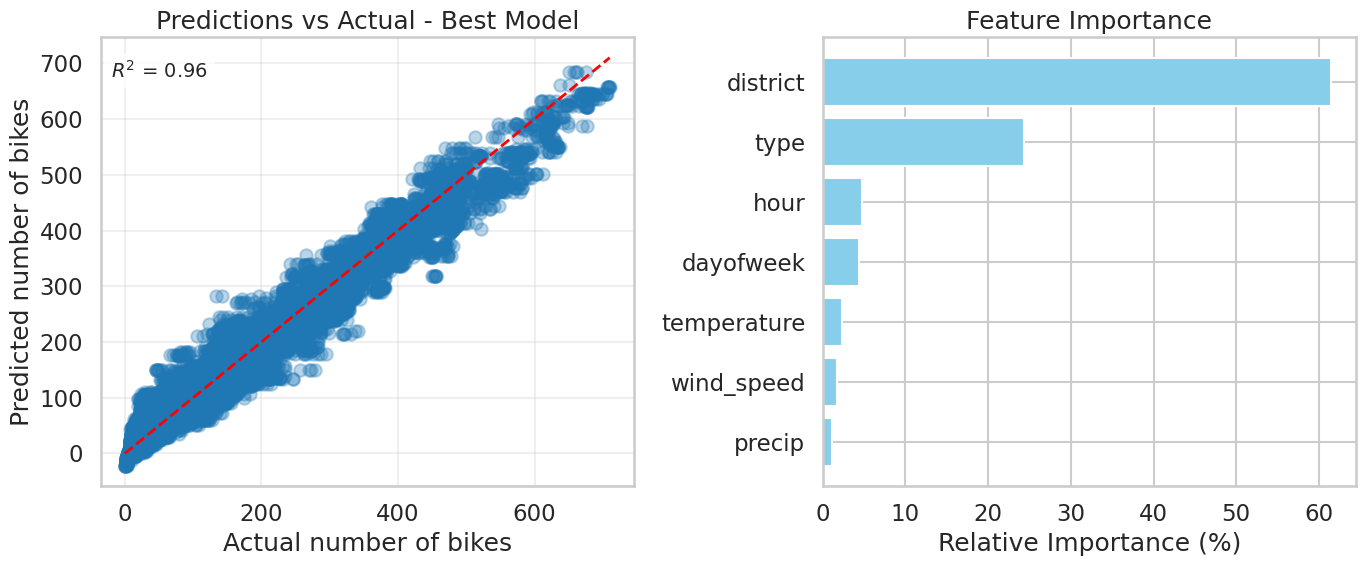

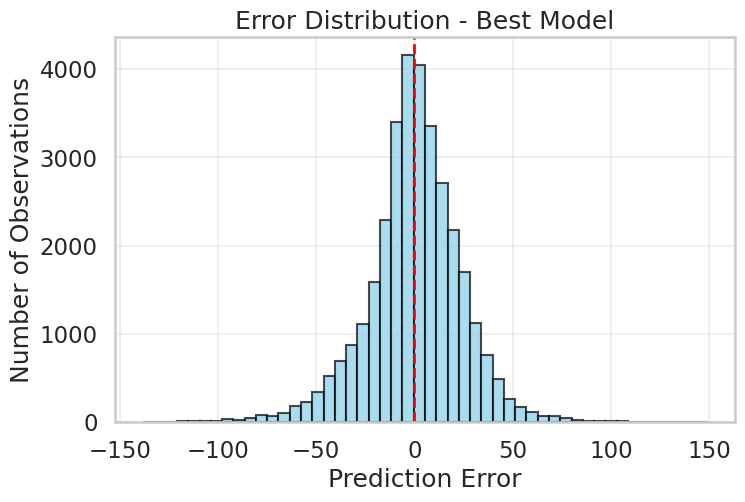

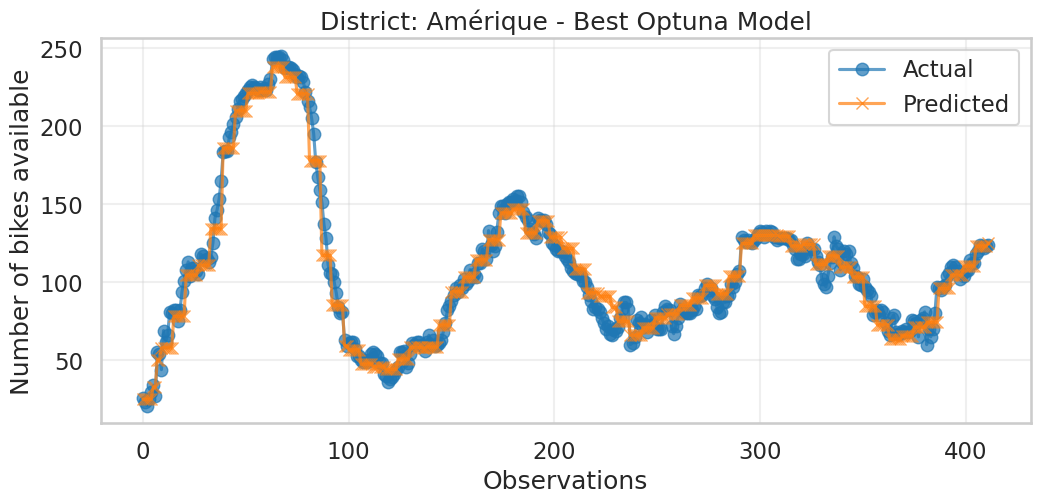

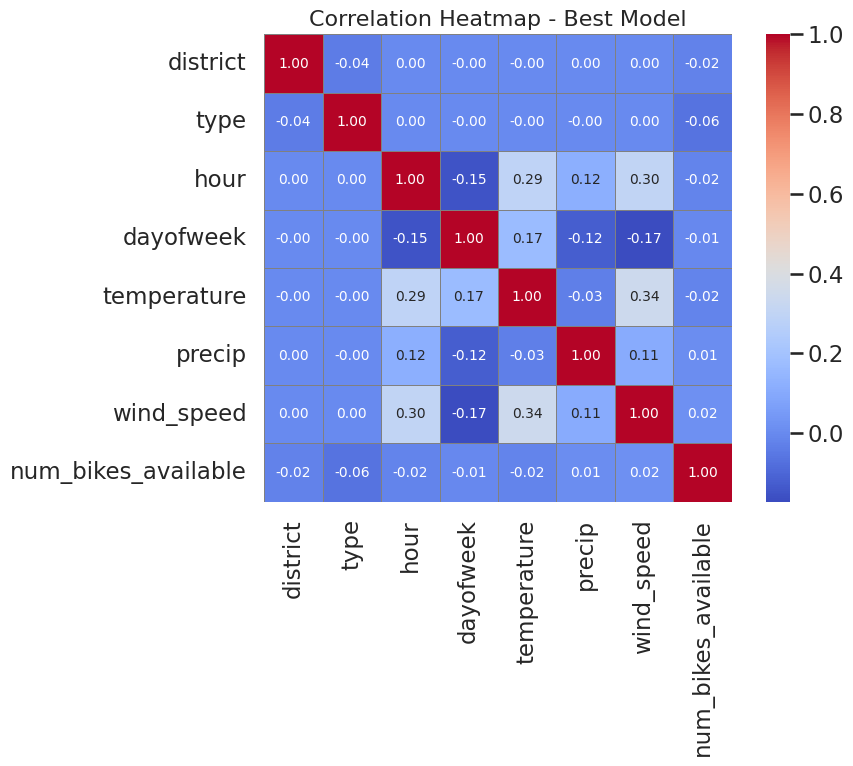


The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.


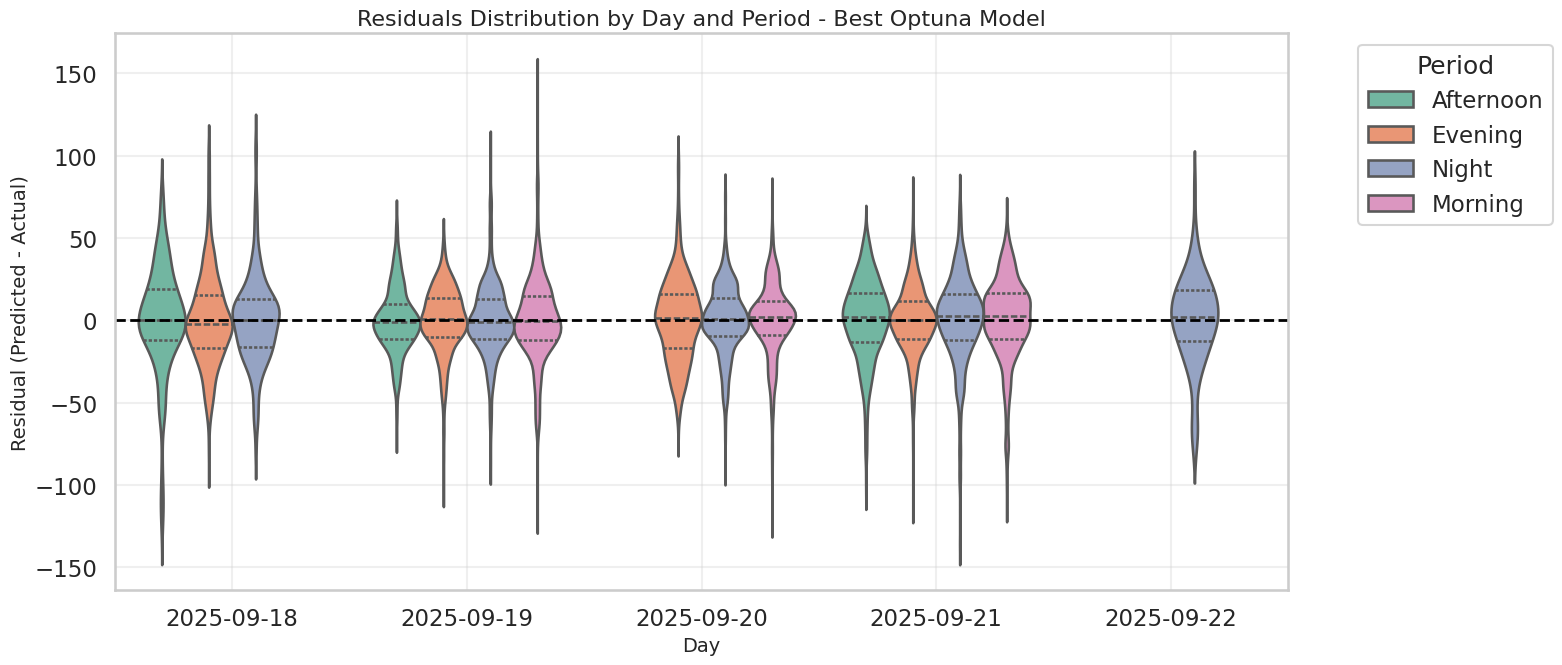

In [21]:
# -----------------------------
# 1️⃣ Feature names
# -----------------------------
feature_names_readable = [
    "district" if f=="l_qu_encoded" else "type" if f=="type_encoded" else f
    for f in X_test.columns
]

# -----------------------------
# 2️⃣ Feature importance
# -----------------------------
importance = best_model.feature_importances_
importance_percent = 100 * importance / importance.sum()
sorted_idx = np.argsort(importance_percent)[::-1]
importance_sorted = importance_percent[sorted_idx]
feature_names_sorted = [feature_names_readable[i] for i in sorted_idx]

# -----------------------------
# 3️⃣ Predictions vs Actual + Feature Importance
# -----------------------------
r2 = r2_score(y_test, best_model.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predictions vs Actual
axes[0].scatter(y_test, best_model.predict(X_test), alpha=0.3)
axes[0].plot([0, max(y_test)], [0, max(y_test)], 'r--', linewidth=2)
axes[0].set_xlabel("Actual number of bikes")
axes[0].set_ylabel("Predicted number of bikes")
axes[0].set_title("Predictions vs Actual - Best Model")
axes[0].text(0.02, 0.95, f"$R^2$ = {r2:.2f}", transform=axes[0].transAxes,
             fontsize=14, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
axes[0].grid(True, alpha=0.3)

# Feature Importance
axes[1].barh(feature_names_sorted, importance_sorted, color='skyblue')
axes[1].invert_yaxis()
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Relative Importance (%)")
plt.tight_layout()
plt.savefig("resFIT.png", dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------
# 4️⃣ Error distribution
# -----------------------------
errors = best_model.predict(X_test) - y_test
plt.figure(figsize=(8,5))
plt.hist(errors, bins=50, color='skyblue', edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Prediction Error")
plt.ylabel("Number of Observations")
plt.title("Error Distribution - Best Model")
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 5️⃣ Time series plot for a sample district
# -----------------------------
sample_qu = 0  # pick the first district
mask = X_test['l_qu_encoded'] == sample_qu
plt.figure(figsize=(12,5))
plt.plot(y_test[mask].values, label="Actual", marker='o', alpha=0.7)
plt.plot(best_model.predict(X_test[mask]), label="Predicted", marker='x', alpha=0.7)
plt.xlabel("Observations")
plt.ylabel("Number of bikes available")
plt.title(f"District: {le_qu.inverse_transform([sample_qu])[0]} - Best Optuna Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 6️⃣ Correlation heatmap
# -----------------------------
df_corr = model_data[config['features'] + ['num_bikes_available']].copy()
df_corr.rename(columns={'l_qu_encoded': 'district', 'type_encoded': 'type'}, inplace=True)
plt.figure(figsize=(10,8))
sns.heatmap(
    df_corr.corr(),
    annot=True, fmt=".2f",
    cmap='coolwarm', cbar=True,
    square=True, linewidths=0.5,
    linecolor='gray', annot_kws={"size":10}
)
plt.title("Correlation Heatmap - Best Model", fontsize=16)
plt.tight_layout()
plt.show()

# -----------------------------
# 7️⃣ Residuals - Violin Plot by Day & Period
# -----------------------------
residuals = best_model.predict(X_test) - y_test
df_res = model_data.iloc[X_test.index].copy()
df_res['residuals'] = residuals

# Ensure datetime parsing
df_res['time_stamp'] = pd.to_datetime(df_res['time_stamp'])
df_res['hour'] = df_res['time_stamp'].dt.hour
df_res['date'] = df_res['time_stamp'].dt.date.astype(str)

# Define periods
def get_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Night"

df_res['period'] = df_res['hour'].apply(get_period)

# Plot: violin by day, color by period
plt.figure(figsize=(16,7))
sns.violinplot(x='date', y='residuals', hue='period', data=df_res,
               split=False, inner='quartile', scale='width',
               palette='Set2')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.ylabel("Residual (Predicted - Actual)", fontsize=14)
plt.xlabel("Day", fontsize=14)
plt.title("Residuals Distribution by Day and Period - Best Optuna Model", fontsize=16)
plt.legend(title="Period", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Fetching weather data...


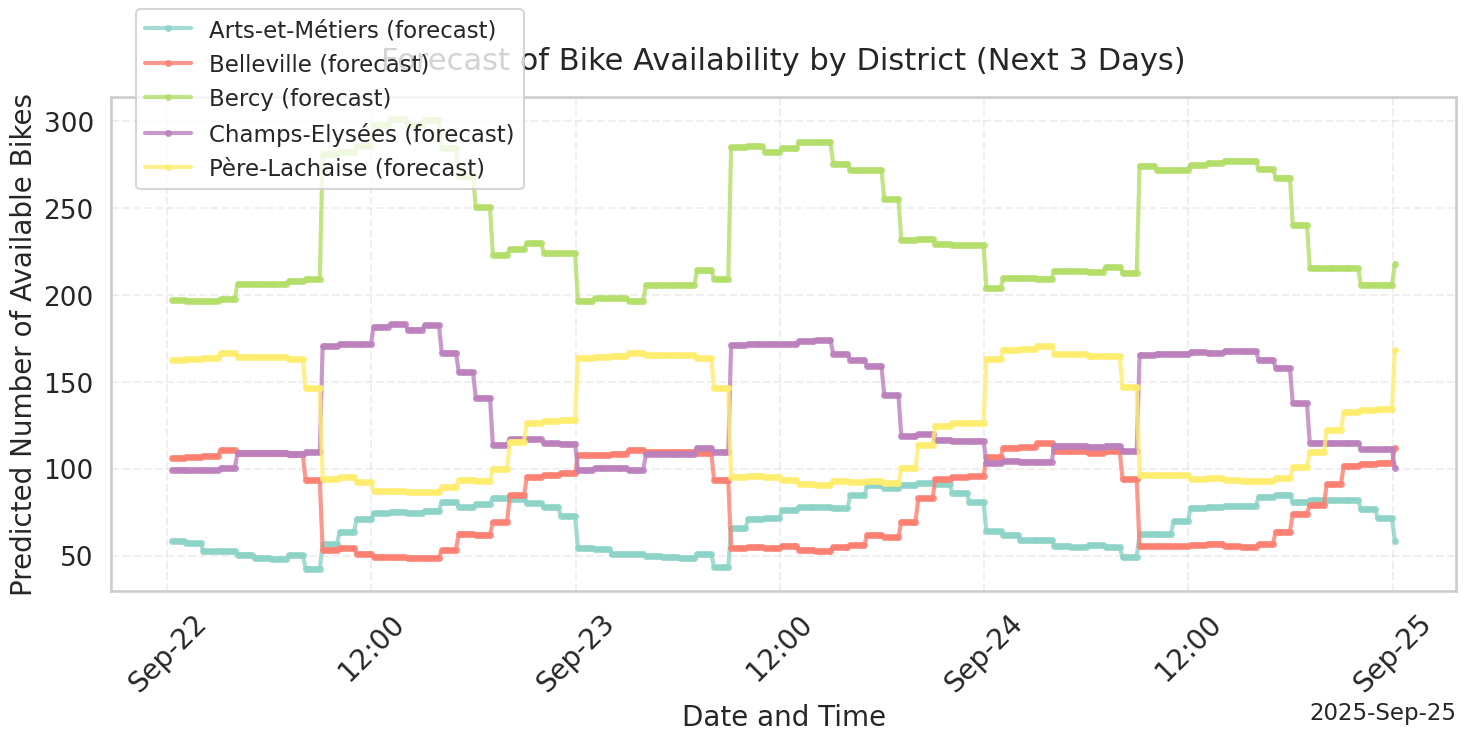

📊 Forecast statistics by district:


,Mean,Max,Min,Std Dev
District,,,,
Arts-et-Métiers,68.400002,91.800003,42.400002,13.900000
Belleville,82.599998,114.599998,48.599998,24.400000
Bercy,239.600006,301.299988,196.699997,34.799999
Champs-Elysées,133.300003,183.300003,99.300003,29.400000
Père-Lachaise,125.300003,170.600006,86.599998,31.900000


In [20]:
# -----------------------------
# 🔮 Predict next 3 days with best model
# -----------------------------
from datetime import timedelta

# --- 1. Generate future timestamps (10-min freq for 3 days) ---
last_time = occupation_data["time_stamp"].max()
future_times = pd.date_range(start=last_time + pd.Timedelta(minutes=10),
                             end=last_time + timedelta(days=3),
                             freq="10min")

# --- 2. Build dataframe for each district ---
future_data = pd.DataFrame([
    {"time_stamp": t, "l_qu": d}
    for d in occupation_data["l_qu"].unique()
    for t in future_times
])

# Temporal features
future_data["hour"] = future_data["time_stamp"].dt.hour
future_data["dayofweek"] = future_data["time_stamp"].dt.dayofweek

# Encode station / district IDs
future_data["l_qu_encoded"] = le_qu.transform(future_data["l_qu"])
future_data["type_qu"] = future_data["l_qu"].map(
    dict(zip(districts_type["l_qu"], districts_type["type_qu"]))
)
future_data["type_encoded"] = le_type.transform(future_data["type_qu"])

# --- 3. Fetch weather forecast for next 3 days ---
future_data = fetch_weather(future_data)

# --- 4. Predict with best model ---
X_future = future_data[best_config['features']]
future_data["predicted_bikes"] = xgb_model.predict(X_future)

# --- 5. Keep only selected districts for plotting ---
future_filtered = future_data[future_data["l_qu"].isin(selected_districts)].copy()

# --- 6. Plot predictions ---
fig, ax = plt.subplots(figsize=(15, 8))

colors = plt.cm.Set3(np.linspace(0, 1, len(found_districts)))

for i, district in enumerate(found_districts):
    district_data = future_filtered[future_filtered["l_qu"] == district].sort_values("time_stamp")
    ax.plot(district_data["time_stamp"], district_data["predicted_bikes"],
            label=f"{district} (forecast)", linewidth=3, alpha=0.8, color=colors[i],
            marker='o', markersize=4)

# Format X-axis
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.tick_params(axis='x', rotation=45, labelsize=20)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.tick_params(axis='y', labelsize=19)

# Titles and labels
ax.set_title("Forecast of Bike Availability by District (Next 3 Days)",
             fontsize=22, pad=20)
ax.set_ylabel("Predicted Number of Available Bikes", fontsize=20)
ax.set_xlabel("Date and Time", fontsize=20)

# Grid + legend
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(bbox_to_anchor=(0.01, 1.2), loc='upper left', frameon=True, fancybox=True)

plt.tight_layout()
plt.show()

# --- 7. Statistics on forecasted data ---
forecast_stats = future_filtered.groupby("l_qu")["predicted_bikes"].agg(['mean', 'max', 'min', 'std'])
forecast_stats = forecast_stats.rename(columns={
    'mean': 'Mean', 
    'max': 'Max', 
    'min': 'Min', 
    'std': 'Std Dev'
})
forecast_stats.index.name = "District"
print("📊 Forecast statistics by district:")
display(forecast_stats.round(1))


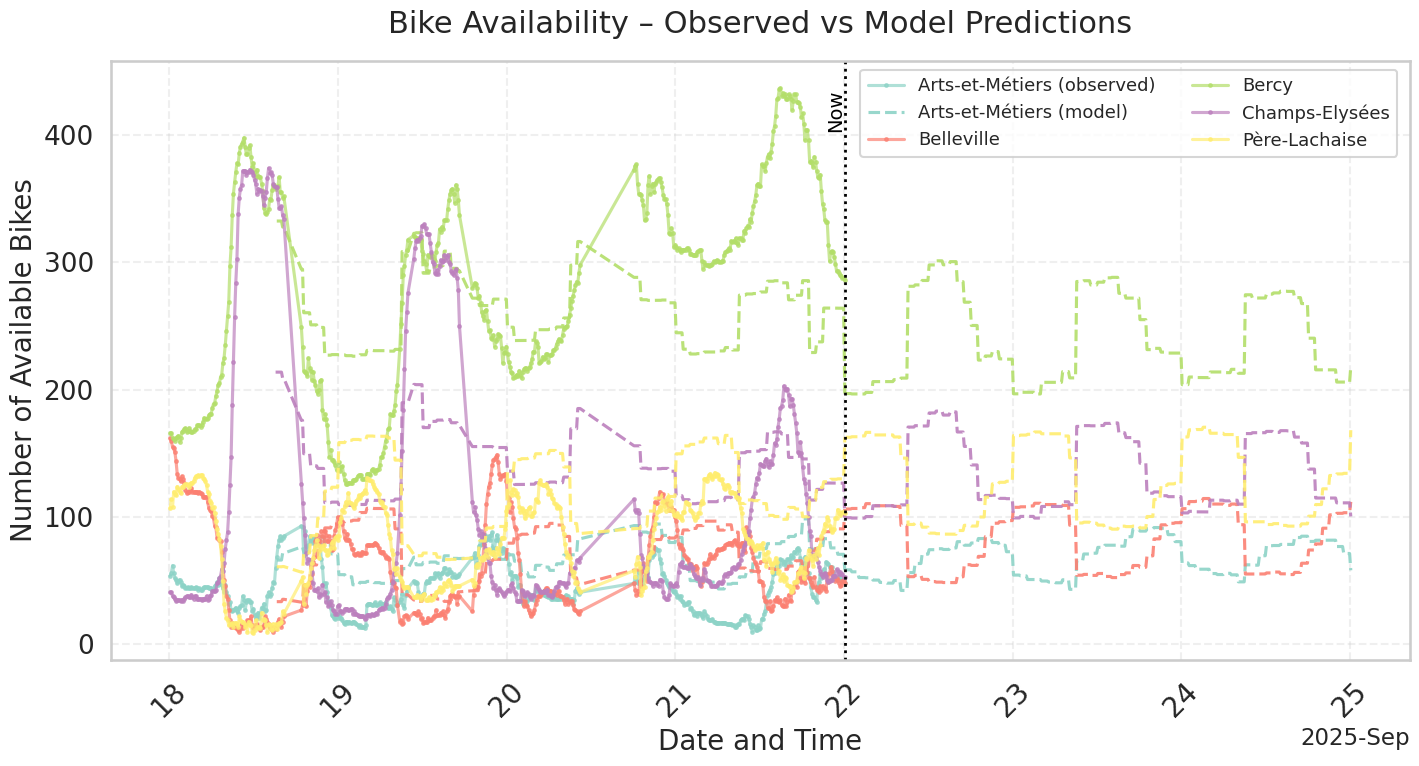

In [36]:
# -----------------------------
# 🔮 Observed + Model Predictions (past + future)
# -----------------------------
fig, ax = plt.subplots(figsize=(15, 8))

colors = plt.cm.Set3(np.linspace(0, 1, len(found_districts)))
last_time = occupation_data["time_stamp"].max()
start_window = last_time - pd.Timedelta(days=4)
end_window = last_time + pd.Timedelta(days=3)

# --- Past predictions (test set of last fold) ---
y_test_pred = xgb_model.predict(X_test)
test_results = X_test.copy()
test_results["time_stamp"] = model_data.loc[X_test.index, "time_stamp"].values
test_results["l_qu"] = model_data.loc[X_test.index, "l_qu"].values
test_results["y_true"] = y_test.values
test_results["y_pred"] = y_test_pred

for i, district in enumerate(found_districts):
    # Observed data
    district_obs = occupation_data_filtered[
        (occupation_data_filtered["l_qu"] == district) &
        (occupation_data_filtered["time_stamp"].between(start_window, end_window))
    ].sort_values("time_stamp")
    
    label_obs = f"{district} (observed)" if district == "Arts-et-Métiers" else district
    ax.plot(district_obs["time_stamp"], district_obs["num_bikes_available"],
            label=label_obs, marker=".", markersize=5, alpha=0.7, color=colors[i])
    
    # Past predictions (test set) -> circles
    district_test = test_results[test_results["l_qu"] == district].sort_values("time_stamp")
    label_test = f"{district} (model)" if district == "Arts-et-Métiers" else None
    ax.plot(district_test["time_stamp"], district_test["y_pred"],
            label=label_test, linestyle="--",# marker="o", markersize=5,
            alpha=0.9, color=colors[i])
    
    # Future predictions (forecast) -> circles
    district_pred = future_filtered[
        (future_filtered["l_qu"] == district) &
        (future_filtered["time_stamp"].between(start_window, end_window))
    ].sort_values("time_stamp")
   # label_forecast = f"{district} (forecast)" if district == "Arts-et-Métiers" else None
    ax.plot(district_pred["time_stamp"], district_pred["predicted_bikes"],
            #label=label_forecast,
            linestyle="--",#, marker="o", markersize=5,
            alpha=0.9, color=colors[i])

# --- Vertical line for "Now" ---
ax.axvline(last_time, color="black", linestyle=":", linewidth=2)
ax.text(last_time, ax.get_ylim()[1]*0.95, "Now", rotation=90,
        verticalalignment="top", horizontalalignment="right",
        fontsize=14, color="black")

# Format X-axis
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.tick_params(axis='x', rotation=45, labelsize=20)
ax.tick_params(axis='y', labelsize=19)

# Titles and labels
ax.set_title("Bike Availability – Observed vs Model Predictions",
             fontsize=22, pad=20)
ax.set_ylabel("Number of Available Bikes", fontsize=20)
ax.set_xlabel("Date and Time", fontsize=20)

# Grid + legend
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(bbox_to_anchor=(0.57, 1), loc='upper left', frameon=True, fancybox=True, fontsize=13, ncol=2)

plt.tight_layout()
plt.savefig("predic.png", dpi=150, bbox_inches='tight')
plt.show()
